<a href="https://colab.research.google.com/github/jumafernandez/ANN-UNSL/blob/main/notebooks/version_4/notebook_06_diagnostico_contaminacion_intradialogo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook independiente — Diagnóstico de contaminación intra-diálogo

Esta notebook verifica si los vecinos recuperados por las variantes estáticas, dinámicas y EMA pertenecen al mismo diálogo que la consulta.

**No reconstruye índices ANN. No llama al LLM. No recalcula juicios.**

Usa únicamente:

- `llm_semantic_scores_pairs_ema_dialog2flow_latest.csv`, si existe en `final_tables`;
- o checkpoints previos (`judgment_checkpoints` + `retrieval_checkpoints`), si el CSV final no existe;
- `dialogs-2.0.pkl`, descargado por ID de Drive sólo si no está cacheado.

## 1. Instalación, imports y montaje de Drive

In [ ]:
!pip install -q gdown pandas numpy matplotlib

In [ ]:
import os
import json
import shutil
import zipfile
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo

import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

print('IN_COLAB:', IN_COLAB)

Mounted at /content/drive
IN_COLAB: True


## 2. Configuración de rutas

La configuración apunta al mismo árbol usado por la notebook 5. Si tus resultados están en otra carpeta, cambiá sólo `DRIVE_BASE_DIR`.

In [ ]:
# ============================================================
# Configuración principal
# ============================================================

if IN_COLAB:
    DRIVE_BASE_DIR = Path('/content/drive/MyDrive/Doctorado/Cursos/ANN/TF')
else:
    # Para ejecución local opcional
    DRIVE_BASE_DIR = Path('.')

INPUT_DIR = DRIVE_BASE_DIR / 'data' / 'id_cache_ema_dialog2flow'
CHECKPOINT_DIR = DRIVE_BASE_DIR / 'resultados' / 'semantic_llm' / 'version_4' / 'checkpoints'
FINAL_DIR = DRIVE_BASE_DIR / 'resultados' / 'semantic_llm' / 'version_4' / 'final_tables'

RETRIEVAL_DIR = CHECKPOINT_DIR / 'retrieval_checkpoints'
JUDGMENT_DIR = CHECKPOINT_DIR / 'judgment_checkpoints'

# Si ejecutás local y tenés un ZIP de final_tables, podés indicarlo acá.
# Si queda en None, la notebook usa FINAL_DIR directamente.
FINAL_TABLES_ZIP = None  # ejemplo: Path('/content/final_tables-20260612T113414Z-3-001.zip')

for d in [INPUT_DIR, FINAL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('DRIVE_BASE_DIR:', DRIVE_BASE_DIR)
print('INPUT_DIR:', INPUT_DIR)
print('FINAL_DIR:', FINAL_DIR)
print('CHECKPOINT_DIR:', CHECKPOINT_DIR)
print('RETRIEVAL_DIR:', RETRIEVAL_DIR)
print('JUDGMENT_DIR:', JUDGMENT_DIR)

DRIVE_BASE_DIR: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF
INPUT_DIR: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/data/id_cache_ema_dialog2flow
FINAL_DIR: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/semantic_llm/version_4/final_tables
CHECKPOINT_DIR: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/semantic_llm/version_4/checkpoints
RETRIEVAL_DIR: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/semantic_llm/version_4/checkpoints/retrieval_checkpoints
JUDGMENT_DIR: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/semantic_llm/version_4/checkpoints/judgment_checkpoints


### 2.1. Extracción opcional de `final_tables` desde ZIP

Usar sólo si no tenés `final_tables` ya montado en Drive. En el flujo normal de Colab no hace falta tocar esto.

In [ ]:
if FINAL_TABLES_ZIP is not None:
    FINAL_TABLES_ZIP = Path(FINAL_TABLES_ZIP)
    if not FINAL_TABLES_ZIP.exists():
        raise FileNotFoundError(FINAL_TABLES_ZIP)

    extract_dir = DRIVE_BASE_DIR / 'resultados' / 'semantic_llm' / 'version_4'
    extract_dir.mkdir(parents=True, exist_ok=True)

    print('Extrayendo:', FINAL_TABLES_ZIP)
    with zipfile.ZipFile(FINAL_TABLES_ZIP, 'r') as zf:
        zf.extractall(extract_dir)

    # Muchos ZIP vienen con carpeta interna final_tables/
    if (extract_dir / 'final_tables').exists():
        FINAL_DIR = extract_dir / 'final_tables'

    print('FINAL_DIR actualizado:', FINAL_DIR)
else:
    print('Sin ZIP externo. Se usa FINAL_DIR directamente.')

Sin ZIP externo. Se usa FINAL_DIR directamente.


## 3. Manifest mínimo de Drive

Sólo necesitamos `dialogs-2.0.pkl` para mapear `row_id -> dialogue_id, turn_id`.

In [ ]:
FILES = {
    'dialogs-2.0.pkl': '1kRbmvg3NB96pWMUl866GZRrT6Zq9vxcb',
}


def download_file(filename: str, force: bool = False) -> Path:
    # Descarga un archivo desde Drive por ID sólo si no existe localmente.
    out_path = INPUT_DIR / filename
    if out_path.exists() and not force:
        print(f'OK cacheado: {filename}')
        return out_path

    if filename not in FILES:
        raise KeyError(f'No hay ID de Drive para {filename}')

    file_id = FILES[filename]
    url = f'https://drive.google.com/uc?id={file_id}'

    print(f'Descargando {filename}')
    print(f'ID: {file_id}')
    gdown.download(url, str(out_path), quiet=False, fuzzy=True)

    if not out_path.exists():
        raise FileNotFoundError(f'No se pudo descargar {filename}')

    return out_path

## 4. Carga del dataset y metadata de diálogo

In [ ]:
dialogs_path = download_file('dialogs-2.0.pkl')
df_dialogs = pd.read_pickle(dialogs_path).reset_index(drop=True)

print('dialogs shape:', df_dialogs.shape)
print('columns:', df_dialogs.columns.tolist())
display(df_dialogs.head())

OK cacheado: dialogs-2.0.pkl
dialogs shape: (1000023, 11)
columns: ['dataset', 'split', 'dialogue_id', 'turn_id', 'speaker', 'utterance', 'domains', 'dialog_acts', 'main_acts', 'slots', 'intents']


,dataset,split,dialogue_id,turn_id,speaker,utterance,domains,dialog_acts,main_acts,slots,intents
0,ABCD,test,ABCD_test_0,0,user,Hi. My name is Chloe Zhang. I am curious as ...,[storewide query],None,None,None,[timing]
1,ABCD,test,ABCD_test_1,0,user,Hello. I recently signed up for a subscription...,[subscription inquiry],None,None,None,[manage dispute bill]
2,ABCD,test,ABCD_test_1,1,user,"sure, it's Albert Sanders and my account id is...",[subscription inquiry],None,None,[account id],None
3,ABCD,test,ABCD_test_1,2,user,yes its 7149958247,[subscription inquiry],None,None,[order id],None
4,ABCD,test,ABCD_test_2,0,user,I'm thinking about buying an item but first i ...,[single item query],None,None,None,[shirt]


In [ ]:
def find_first_existing_column(df: pd.DataFrame, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

# Nombres esperados en Dialog2Flow, con fallbacks por robustez.
dialogue_col = find_first_existing_column(
    df_dialogs,
    [
        'dialogue_id', 'dialog_id', 'conversation_id', 'conversationId',
        'conv_id', 'dialogue', 'dialog'
    ]
)

turn_col = find_first_existing_column(
    df_dialogs,
    [
        'turn_id', 'turn_idx', 'turn_index', 'turn', 'turn_number',
        'utterance_id'
    ]
)

if dialogue_col is None:
    raise ValueError('No pude detectar columna de diálogo. Revisar columnas impresas arriba.')

row_meta = df_dialogs.reset_index().rename(columns={'index': 'row_id'})

if turn_col is None:
    print('No detecté columna de turno. Derivo turn_id por orden dentro de cada diálogo.')
    row_meta['_derived_turn_id'] = row_meta.groupby(dialogue_col).cumcount()
    turn_col = '_derived_turn_id'

row_meta = row_meta[['row_id', dialogue_col, turn_col]].rename(
    columns={
        dialogue_col: 'dialogue_id',
        turn_col: 'turn_id',
    }
)

row_meta['row_id'] = row_meta['row_id'].astype(int)

print('Columna de diálogo usada:', dialogue_col)
print('Columna de turno usada:', turn_col)
display(row_meta.head())

Columna de diálogo usada: dialogue_id
Columna de turno usada: turn_id


,row_id,dialogue_id,turn_id
0,0,ABCD_test_0,0
1,1,ABCD_test_1,0
2,2,ABCD_test_1,1
3,3,ABCD_test_1,2
4,4,ABCD_test_2,0


## 5. Carga de resultados existentes

Orden de prioridad:

1. `llm_semantic_scores_pairs_ema_dialog2flow_latest.csv` desde `final_tables`.
2. Si no existe, reconstrucción desde `judgment_checkpoints` + `retrieval_checkpoints`.

En ambos casos se reutilizan archivos ya generados.

In [ ]:
SCORES_LATEST = FINAL_DIR / 'llm_semantic_scores_pairs_ema_dialog2flow_latest.csv'
RETRIEVAL_LATEST = FINAL_DIR / 'retrieval_top10_textual_ema_dialog2flow_latest.csv'


def read_all_judgments_from_checkpoints(judgment_dir: Path) -> pd.DataFrame:
    records = []
    files = sorted(judgment_dir.glob('judgments__*.jsonl'))
    print('Archivos de juicios encontrados:', len(files))

    for path in files:
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.strip():
                    continue
                try:
                    rec = json.loads(line)
                except Exception:
                    continue

                evaluations = rec.get('evaluations', [])
                for ev in evaluations:
                    ev_clean = dict(ev)
                    if 'rank' in ev_clean and 'neighbor_rank' not in ev_clean:
                        ev_clean['neighbor_rank'] = ev_clean.pop('rank')

                    records.append({
                        'embedding_base': rec.get('embedding_base'),
                        'variant': rec.get('variant'),
                        'index_type': rec.get('index_type'),
                        'query_order': rec.get('query_order'),
                        'query_row': rec.get('query_row'),
                        'model': rec.get('model'),
                        **ev_clean,
                    })

    return pd.DataFrame(records)


def read_all_retrieval_from_checkpoints(retrieval_dir: Path) -> pd.DataFrame:
    files = sorted(retrieval_dir.glob('retrieval__*.csv'))
    print('Archivos retrieval encontrados:', len(files))
    if not files:
        return pd.DataFrame()
    return pd.concat([pd.read_csv(path) for path in files], ignore_index=True)


def load_scores_pairs() -> pd.DataFrame:
    if SCORES_LATEST.exists():
        print('Leyendo scores finales:', SCORES_LATEST)
        out = pd.read_csv(SCORES_LATEST)
    else:
        print('No existe scores_latest. Reconstruyendo desde checkpoints...')
        scores_raw = read_all_judgments_from_checkpoints(JUDGMENT_DIR)

        if RETRIEVAL_LATEST.exists():
            print('Leyendo retrieval final:', RETRIEVAL_LATEST)
            retrieval = pd.read_csv(RETRIEVAL_LATEST)
        else:
            print('No existe retrieval_latest. Reconstruyendo retrieval desde checkpoints...')
            retrieval = read_all_retrieval_from_checkpoints(RETRIEVAL_DIR)

        if scores_raw.empty:
            raise ValueError('No se encontraron juicios LLM en checkpoints.')
        if retrieval.empty:
            raise ValueError('No se encontraron archivos de retrieval en final_tables ni checkpoints.')

        merge_cols = [
            'embedding_base', 'variant', 'index_type',
            'query_order', 'query_row', 'neighbor_rank'
        ]

        # Asegurar tipos compatibles.
        for col in ['query_order', 'query_row', 'neighbor_rank']:
            if col in scores_raw.columns:
                scores_raw[col] = scores_raw[col].astype(int)
            if col in retrieval.columns:
                retrieval[col] = retrieval[col].astype(int)

        out = scores_raw.merge(
            retrieval,
            on=merge_cols,
            how='left',
            validate='many_to_one',
        )

    if 'rank' in out.columns and 'neighbor_rank' not in out.columns:
        out = out.rename(columns={'rank': 'neighbor_rank'})

    required_cols = {
        'variant', 'index_type', 'query_order', 'query_row',
        'neighbor_rank', 'neighbor_row', 'overall_similarity'
    }
    missing = required_cols - set(out.columns)
    if missing:
        raise ValueError(f'Faltan columnas necesarias: {missing}')

    for col in ['query_order', 'query_row', 'neighbor_rank', 'neighbor_row']:
        out[col] = out[col].astype(int)

    out['overall_similarity'] = pd.to_numeric(out['overall_similarity'], errors='coerce')

    dedup_cols = [
        'embedding_base', 'variant', 'index_type', 'query_order',
        'query_row', 'neighbor_rank', 'neighbor_row'
    ]
    before = len(out)
    out = out.drop_duplicates(subset=[c for c in dedup_cols if c in out.columns], keep='last')
    after = len(out)
    if after != before:
        print(f'Duplicados removidos: {before - after}')

    return out


df_scores = load_scores_pairs()

print('df_scores shape:', df_scores.shape)
print('variants:', sorted(df_scores['variant'].dropna().unique().tolist()))
print('indices:', sorted(df_scores['index_type'].dropna().unique().tolist()))
display(df_scores.head())

Leyendo scores finales: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/semantic_llm/version_4/final_tables/llm_semantic_scores_pairs_ema_dialog2flow_latest.csv
df_scores shape: (33000, 21)
variants: ['dinamico', 'ema_alpha_0_1', 'ema_alpha_0_2', 'ema_alpha_0_3', 'ema_alpha_0_4', 'ema_alpha_0_5', 'ema_alpha_0_6', 'ema_alpha_0_7', 'ema_alpha_0_8', 'ema_alpha_0_9', 'estatico']
indices: ['HNSW', 'IVF', 'IVFPQ']


,embedding_base,variant,index_type,query_order,query_row,model,neighbor_rank,semantic_similarity,functional_similarity,memory_usefulness,...,brief_reason,embedding_name,neighbor_row,distance,query_utterance,neighbor_utterance,query_context,neighbor_context,build_time_s,search_time_s
0,Dialog2Flow,dinamico,HNSW,0,380462,gpt-4.1-mini,1,5,5,5,...,Exact same dialogue with identical user and sy...,dialog2flow-joint-bert-base,940881,6.884739e-14,"Okay. I'm showing 3 flight options for you, in...","Okay. I'm showing 3 flight options for you, in...","[5] system: And, what's the city you want for ...","[5] system: And, what's the city you want for ...",906.860261,0.102842
1,Dialog2Flow,dinamico,HNSW,0,380462,gpt-4.1-mini,2,4,4,4,...,"Same departure city question and answer, but m...",dialog2flow-joint-bert-base,940880,1.018667e-01,"Okay. I'm showing 3 flight options for you, in...","I want to fly out of Atlanta, GA.","[5] system: And, what's the city you want for ...",[4] user: I'd like to fly out on the 13th of t...,906.860261,0.102842
2,Dialog2Flow,dinamico,HNSW,0,380462,gpt-4.1-mini,3,4,4,4,...,"Same as neighbor 2, repeated; clear semantic a...",dialog2flow-joint-bert-base,380461,1.018667e-01,"Okay. I'm showing 3 flight options for you, in...","I want to fly out of Atlanta, GA.","[5] system: And, what's the city you want for ...",[4] user: I'd like to fly out on the 13th of t...,906.860261,0.102842
3,Dialog2Flow,dinamico,HNSW,0,380462,gpt-4.1-mini,4,4,4,4,...,Includes user departure city and system flight...,dialog2flow-joint-bert-base,940882,1.146467e-01,"Okay. I'm showing 3 flight options for you, in...",What's the destination airport and arrival tim...,"[5] system: And, what's the city you want for ...","[6] user: I want to fly out of Atlanta, GA.\n[...",906.860261,0.102842
4,Dialog2Flow,dinamico,HNSW,0,380462,gpt-4.1-mini,5,4,4,4,...,"Same as neighbor 4, repeated; maintains clear ...",dialog2flow-joint-bert-base,380463,1.146467e-01,"Okay. I'm showing 3 flight options for you, in...",What's the destination airport and arrival tim...,"[5] system: And, what's the city you want for ...","[6] user: I want to fly out of Atlanta, GA.\n[...",906.860261,0.102842


## 6. Enriquecimiento con `dialogue_id` y `turn_id`

In [ ]:
scores = df_scores.copy()

scores = scores.merge(
    row_meta.rename(columns={
        'row_id': 'query_row',
        'dialogue_id': 'query_dialogue_id',
        'turn_id': 'query_turn_id',
    }),
    on='query_row',
    how='left',
    validate='many_to_one',
)

scores = scores.merge(
    row_meta.rename(columns={
        'row_id': 'neighbor_row',
        'dialogue_id': 'neighbor_dialogue_id',
        'turn_id': 'neighbor_turn_id',
    }),
    on='neighbor_row',
    how='left',
    validate='many_to_one',
)

missing_query_meta = scores['query_dialogue_id'].isna().sum()
missing_neighbor_meta = scores['neighbor_dialogue_id'].isna().sum()
print('missing query metadata:', missing_query_meta)
print('missing neighbor metadata:', missing_neighbor_meta)

if missing_query_meta or missing_neighbor_meta:
    raise ValueError('Hay filas sin metadata de diálogo. Revisar query_row / neighbor_row.')

scores['same_dialogue'] = (
    scores['query_dialogue_id'].astype(str)
    == scores['neighbor_dialogue_id'].astype(str)
)

scores['turn_distance'] = (
    scores['query_turn_id'].astype(float)
    - scores['neighbor_turn_id'].astype(float)
).abs()

# Distancia 0 incluye el mismo turno si hubiera duplicación exacta por row.
# Distancia <= 1 detecta el caso más peligroso: mismo turno o turno vecino.
scores['same_dialogue_adjacent'] = scores['same_dialogue'] & (scores['turn_distance'] <= 1)

print('scores enriched shape:', scores.shape)
display(scores[[
    'variant', 'index_type', 'query_order', 'query_row', 'neighbor_rank', 'neighbor_row',
    'query_dialogue_id', 'neighbor_dialogue_id', 'query_turn_id', 'neighbor_turn_id',
    'same_dialogue', 'turn_distance', 'overall_similarity'
]].head())

missing query metadata: 0
missing neighbor metadata: 0
scores enriched shape: (33000, 28)


,variant,index_type,query_order,query_row,neighbor_rank,neighbor_row,query_dialogue_id,neighbor_dialogue_id,query_turn_id,neighbor_turn_id,same_dialogue,turn_distance,overall_similarity
0,dinamico,HNSW,0,380462,1,940881,KETOD_train_1252,SGD_train_7042,7,7,False,0.0,5
1,dinamico,HNSW,0,380462,2,940880,KETOD_train_1252,SGD_train_7042,7,6,False,1.0,4
2,dinamico,HNSW,0,380462,3,380461,KETOD_train_1252,KETOD_train_1252,7,6,True,1.0,4
3,dinamico,HNSW,0,380462,4,940882,KETOD_train_1252,SGD_train_7042,7,8,False,1.0,4
4,dinamico,HNSW,0,380462,5,380463,KETOD_train_1252,KETOD_train_1252,7,8,True,1.0,4


## 7. Diagnóstico principal por variante e índice

Métricas:

- `% same-dialogue neighbors@10`: porcentaje de pares query-vecino del top-10 que pertenecen al mismo diálogo.
- `% adjacent same-dialogue neighbors@10`: porcentaje de pares del mismo diálogo con distancia de turno <= 1.
- `% queries with same-dialogue neighbor`: porcentaje de consultas que tienen al menos un vecino del mismo diálogo.
- `mean same-dialogue neighbors/query`: promedio de vecinos del mismo diálogo por consulta.
- `MSS same-dialogue pairs` vs `MSS cross-dialogue pairs`: score medio de pares intra-diálogo y cross-diálogo.

In [ ]:
pair_summary = (
    scores
    .groupby(['variant', 'index_type'], as_index=False)
    .agg(
        n_pairs=('same_dialogue', 'size'),
        pct_same_dialogue_neighbors_at10=('same_dialogue', 'mean'),
        pct_adjacent_same_dialogue_neighbors_at10=('same_dialogue_adjacent', 'mean'),
        mean_overall_similarity_all=('overall_similarity', 'mean'),
    )
)

query_level = (
    scores
    .groupby(['variant', 'index_type', 'query_order'], as_index=False)
    .agg(
        has_same_dialogue_neighbor=('same_dialogue', 'any'),
        n_same_dialogue_neighbors=('same_dialogue', 'sum'),
        has_adjacent_same_dialogue_neighbor=('same_dialogue_adjacent', 'any'),
        n_adjacent_same_dialogue_neighbors=('same_dialogue_adjacent', 'sum'),
        mss_at10=('overall_similarity', 'mean'),
    )
)

query_summary = (
    query_level
    .groupby(['variant', 'index_type'], as_index=False)
    .agg(
        n_queries=('query_order', 'nunique'),
        pct_queries_with_same_dialogue_neighbor=('has_same_dialogue_neighbor', 'mean'),
        mean_same_dialogue_neighbors_per_query=('n_same_dialogue_neighbors', 'mean'),
        pct_queries_with_adjacent_same_dialogue_neighbor=('has_adjacent_same_dialogue_neighbor', 'mean'),
        mean_adjacent_same_dialogue_neighbors_per_query=('n_adjacent_same_dialogue_neighbors', 'mean'),
        mean_mss_at10=('mss_at10', 'mean'),
    )
)

score_split = (
    scores
    .groupby(['variant', 'index_type', 'same_dialogue'], as_index=False)
    .agg(
        mean_overall_similarity=('overall_similarity', 'mean'),
        n_pairs_split=('overall_similarity', 'size'),
    )
)

score_split_wide = (
    score_split
    .pivot_table(
        index=['variant', 'index_type'],
        columns='same_dialogue',
        values='mean_overall_similarity',
    )
    .rename(columns={
        False: 'mean_overall_similarity_cross_dialogue',
        True: 'mean_overall_similarity_same_dialogue',
    })
    .reset_index()
)

diagnostic = (
    pair_summary
    .merge(query_summary, on=['variant', 'index_type'], how='left')
    .merge(score_split_wide, on=['variant', 'index_type'], how='left')
)

diagnostic['delta_same_vs_cross_similarity'] = (
    diagnostic['mean_overall_similarity_same_dialogue']
    - diagnostic['mean_overall_similarity_cross_dialogue']
)

In [ ]:
def variant_order(v):
    v = str(v)
    if v == 'estatico':
        return -2
    if v == 'dinamico':
        return -1
    if v.startswith('ema_alpha_'):
        try:
            return float(v.replace('ema_alpha_', '').replace('_', '.'))
        except Exception:
            return 99
    return 99

index_order_map = {'IVF': 0, 'HNSW': 1, 'IVFPQ': 2}


def order_df(df_in):
    out = df_in.copy()
    out['_variant_order'] = out['variant'].map(variant_order)
    out['_index_order'] = out['index_type'].map(index_order_map).fillna(99)
    out = out.sort_values(['_variant_order', '_index_order'])
    return out.drop(columns=['_variant_order', '_index_order'])


diagnostic = order_df(diagnostic)

pct_cols = [
    'pct_same_dialogue_neighbors_at10',
    'pct_adjacent_same_dialogue_neighbors_at10',
    'pct_queries_with_same_dialogue_neighbor',
    'pct_queries_with_adjacent_same_dialogue_neighbor',
]

for col in pct_cols:
    diagnostic[col] = 100 * diagnostic[col]

float_cols = diagnostic.select_dtypes(include=['float']).columns
diagnostic[float_cols] = diagnostic[float_cols].round(3)

compact_cols = [
    'variant',
    'index_type',
    'n_queries',
    'mean_mss_at10',
    'pct_same_dialogue_neighbors_at10',
    'pct_queries_with_same_dialogue_neighbor',
    'mean_same_dialogue_neighbors_per_query',
    'pct_adjacent_same_dialogue_neighbors_at10',
    'mean_overall_similarity_same_dialogue',
    'mean_overall_similarity_cross_dialogue',
    'delta_same_vs_cross_similarity',
]

diagnostic_compact = diagnostic[compact_cols].copy()

display(diagnostic_compact)

,variant,index_type,n_queries,mean_mss_at10,pct_same_dialogue_neighbors_at10,pct_queries_with_same_dialogue_neighbor,mean_same_dialogue_neighbors_per_query,pct_adjacent_same_dialogue_neighbors_at10,mean_overall_similarity_same_dialogue,mean_overall_similarity_cross_dialogue,delta_same_vs_cross_similarity
31,estatico,IVF,100,3.294,0.0,0.0,0.00,0.0,NaN,3.294,NaN
30,estatico,HNSW,100,3.293,0.0,0.0,0.00,0.0,NaN,3.293,NaN
32,estatico,IVFPQ,100,3.296,0.0,0.0,0.00,0.0,NaN,3.296,NaN
1,dinamico,IVF,100,3.665,23.1,93.0,2.31,16.1,3.823,3.618,0.205
0,dinamico,HNSW,100,3.661,23.2,93.0,2.32,16.2,3.862,3.600,0.262
2,dinamico,IVFPQ,100,3.647,14.4,74.0,1.44,11.4,4.021,3.584,0.437
4,ema_alpha_0_1,IVF,100,3.180,54.4,97.0,5.44,17.3,2.846,3.579,-0.733
3,ema_alpha_0_1,HNSW,100,3.203,54.5,97.0,5.45,17.3,2.901,3.565,-0.664
5,ema_alpha_0_1,IVFPQ,100,3.181,51.9,97.0,5.19,17.0,2.919,3.464,-0.545
7,ema_alpha_0_2,IVF,100,3.260,52.8,96.0,5.28,17.2,2.919,3.642,-0.723


## 8. Tabla pivote rápida: estático vs dinámico vs EMA

Esta tabla permite ver si el porcentaje de vecinos del mismo diálogo sube especialmente en las representaciones acumulativas.

In [ ]:
pivot_same_dialogue = diagnostic_compact.pivot_table(
    index='variant',
    columns='index_type',
    values='pct_same_dialogue_neighbors_at10',
    aggfunc='mean',
)

pivot_same_dialogue = pivot_same_dialogue.reindex(
    sorted(pivot_same_dialogue.index, key=variant_order)
)

print('% same-dialogue neighbors@10')
display(pivot_same_dialogue.round(2))

pivot_queries_same = diagnostic_compact.pivot_table(
    index='variant',
    columns='index_type',
    values='pct_queries_with_same_dialogue_neighbor',
    aggfunc='mean',
)

pivot_queries_same = pivot_queries_same.reindex(
    sorted(pivot_queries_same.index, key=variant_order)
)

print('% queries with at least one same-dialogue neighbor')
display(pivot_queries_same.round(2))

% same-dialogue neighbors@10


index_type,HNSW,IVF,IVFPQ
variant,,,
estatico,0.0,0.0,0.0
dinamico,23.2,23.1,14.4
ema_alpha_0_1,54.5,54.4,51.9
ema_alpha_0_2,52.6,52.8,47.3
ema_alpha_0_3,45.6,45.5,38.5
ema_alpha_0_4,35.1,34.9,25.0
ema_alpha_0_5,23.2,23.0,14.0
ema_alpha_0_6,12.9,12.9,6.2
ema_alpha_0_7,4.6,4.6,1.9


% queries with at least one same-dialogue neighbor


index_type,HNSW,IVF,IVFPQ
variant,,,
estatico,0.0,0.0,0.0
dinamico,93.0,93.0,74.0
ema_alpha_0_1,97.0,97.0,97.0
ema_alpha_0_2,96.0,96.0,96.0
ema_alpha_0_3,95.0,96.0,95.0
ema_alpha_0_4,96.0,96.0,93.0
ema_alpha_0_5,93.0,93.0,74.0
ema_alpha_0_6,71.0,72.0,47.0
ema_alpha_0_7,33.0,34.0,15.0


## 9. Diagnóstico por rank

Esto permite detectar si el problema está concentrado en los primeros vecinos.

In [ ]:
by_rank = (
    scores
    .groupby(['variant', 'index_type', 'neighbor_rank'], as_index=False)
    .agg(
        pct_same_dialogue=('same_dialogue', 'mean'),
        pct_adjacent_same_dialogue=('same_dialogue_adjacent', 'mean'),
        mean_overall_similarity=('overall_similarity', 'mean'),
        n_pairs=('overall_similarity', 'size'),
    )
)

for col in ['pct_same_dialogue', 'pct_adjacent_same_dialogue']:
    by_rank[col] = 100 * by_rank[col]

float_cols_rank = by_rank.select_dtypes(include=['float']).columns
by_rank[float_cols_rank] = by_rank[float_cols_rank].round(3)
by_rank = order_df(by_rank)

display(by_rank.head(30))

,variant,index_type,neighbor_rank,pct_same_dialogue,pct_adjacent_same_dialogue,mean_overall_similarity,n_pairs
310,estatico,IVF,1,0.0,0.0,4.15,100
311,estatico,IVF,2,0.0,0.0,3.82,100
312,estatico,IVF,3,0.0,0.0,3.39,100
313,estatico,IVF,4,0.0,0.0,3.32,100
314,estatico,IVF,5,0.0,0.0,3.03,100
315,estatico,IVF,6,0.0,0.0,3.04,100
316,estatico,IVF,7,0.0,0.0,3.07,100
317,estatico,IVF,8,0.0,0.0,3.05,100
318,estatico,IVF,9,0.0,0.0,3.05,100
319,estatico,IVF,10,0.0,0.0,3.02,100


## 10. Visualizaciones diagnósticas

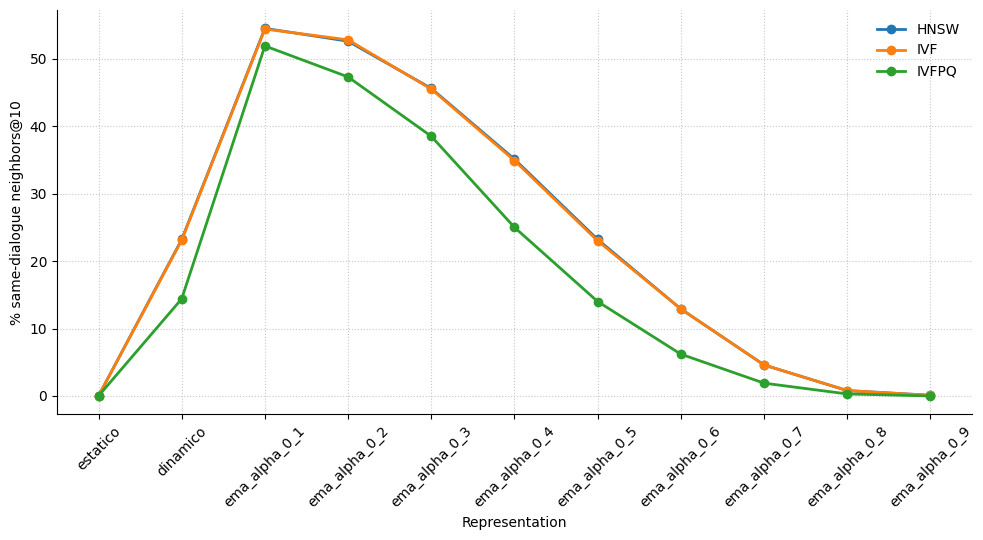

In [ ]:
plot_df = diagnostic_compact.copy()
plot_df['_variant_order'] = plot_df['variant'].map(variant_order)
plot_df = plot_df.sort_values(['_variant_order', 'index_type'])

fig, ax = plt.subplots(figsize=(10, 5.5))

for index_type, g in plot_df.groupby('index_type', sort=False):
    ax.plot(
        g['variant'],
        g['pct_same_dialogue_neighbors_at10'],
        marker='o',
        linewidth=2,
        label=index_type,
    )

ax.set_xlabel('Representation')
ax.set_ylabel('% same-dialogue neighbors@10')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, linestyle=':', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

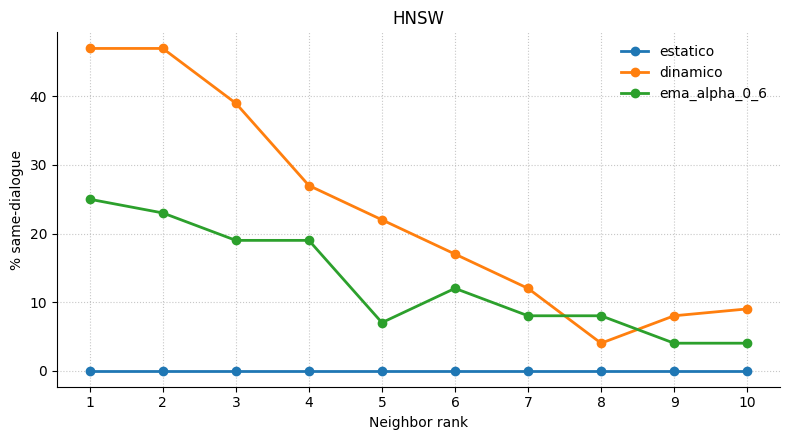

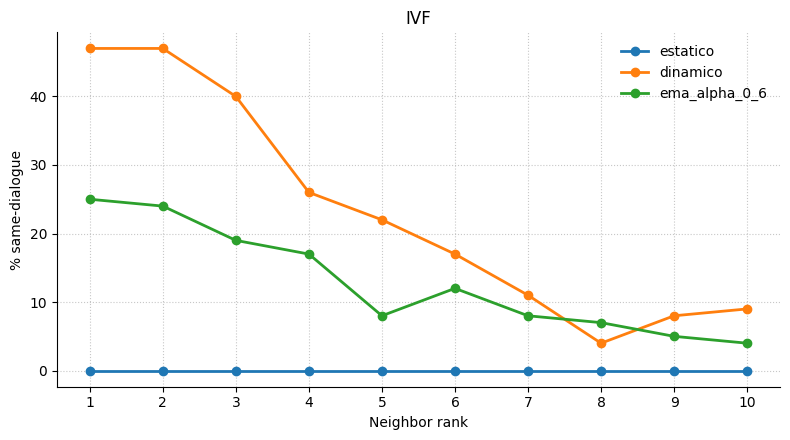

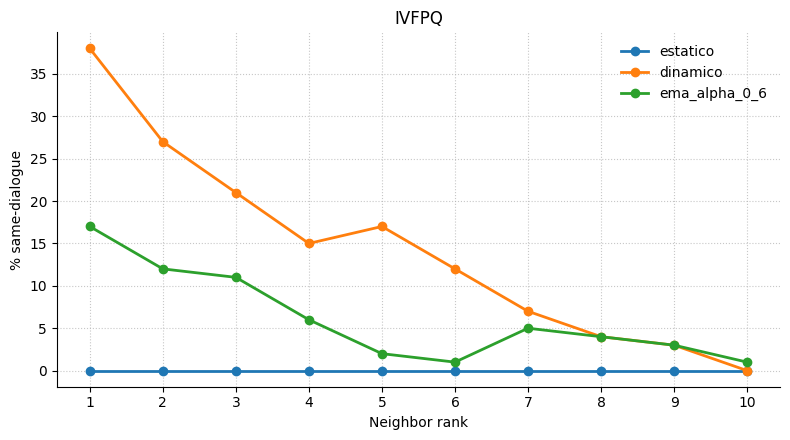

In [ ]:
variants_to_plot = ['estatico', 'dinamico', 'ema_alpha_0_6']
rank_plot_df = by_rank[by_rank['variant'].isin(variants_to_plot)].copy()
rank_plot_df['_variant_order'] = rank_plot_df['variant'].map(variant_order)
rank_plot_df = rank_plot_df.sort_values(['_variant_order', 'index_type', 'neighbor_rank'])

for index_type in rank_plot_df['index_type'].dropna().unique():
    fig, ax = plt.subplots(figsize=(8, 4.5))
    g_index = rank_plot_df[rank_plot_df['index_type'] == index_type]

    for variant, g in g_index.groupby('variant', sort=False):
        ax.plot(
            g['neighbor_rank'],
            g['pct_same_dialogue'],
            marker='o',
            linewidth=2,
            label=variant,
        )

    ax.set_xlabel('Neighbor rank')
    ax.set_ylabel('% same-dialogue')
    ax.set_title(index_type)
    ax.set_xticks(sorted(g_index['neighbor_rank'].unique()))
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

## 11. Ejemplos concretos de vecinos intra-diálogo

Sirve para inspeccionar casos cualitativos y ver si son vecinos triviales del mismo diálogo.

In [ ]:
EXAMPLE_VARIANT = 'ema_alpha_0_6'
EXAMPLE_INDEX = 'IVF'
N_EXAMPLES = 20

example_cols = [
    'variant', 'index_type', 'query_order', 'query_row', 'neighbor_rank', 'neighbor_row',
    'query_dialogue_id', 'neighbor_dialogue_id', 'query_turn_id', 'neighbor_turn_id',
    'turn_distance', 'overall_similarity'
]

for c in ['query_utterance', 'neighbor_utterance', 'query_context', 'neighbor_context', 'brief_reason']:
    if c in scores.columns:
        example_cols.append(c)

examples = scores[
    (scores['variant'] == EXAMPLE_VARIANT)
    & (scores['index_type'] == EXAMPLE_INDEX)
    & (scores['same_dialogue'])
].sort_values(['query_order', 'neighbor_rank'])

print(f'Ejemplos same-dialogue para {EXAMPLE_VARIANT} / {EXAMPLE_INDEX}:')
display(examples[example_cols].head(N_EXAMPLES))

Ejemplos same-dialogue para ema_alpha_0_6 / IVF:


,variant,index_type,query_order,query_row,neighbor_rank,neighbor_row,query_dialogue_id,neighbor_dialogue_id,query_turn_id,neighbor_turn_id,turn_distance,overall_similarity,query_utterance,neighbor_utterance,query_context,neighbor_context,brief_reason
19040,ema_alpha_0_6,IVF,4,956850,1,956849,SGD_train_7771,SGD_train_7771,8,7,1.0,5,I would like an appointment tomorrow.,What date would you like your appointment?,"[6] user: Yes, book it for afternoon 12:30.\n[...",[5] system: Would you like to book an appointm...,Exact match in dialogue flow and content about...
19083,ema_alpha_0_6,IVF,8,643250,4,643249,MultiWOZ_2.1_train_6081,MultiWOZ_2.1_train_6081,1,0,1.0,3,Absolutely. We have plenty of options. Looking...,"Hi, can you suggest some attractions I could v...","[0] user: Hi, can you suggest some attractions...","[0] user: Hi, can you suggest some attractions...","Same as rank 3, user utterance only, no system..."
19085,ema_alpha_0_6,IVF,8,643250,6,643251,MultiWOZ_2.1_train_6081,MultiWOZ_2.1_train_6081,1,2,1.0,4,Absolutely. We have plenty of options. Looking...,Can you look for something in the east?,"[0] user: Hi, can you suggest some attractions...","[0] user: Hi, can you suggest some attractions...","Same as rank 5, user and system utterances mat..."
19086,ema_alpha_0_6,IVF,8,643250,7,643252,MultiWOZ_2.1_train_6081,MultiWOZ_2.1_train_6081,1,3,2.0,3,Absolutely. We have plenty of options. Looking...,"There are museums, a park, a pool, multiple sp...","[0] user: Hi, can you suggest some attractions...",[1] system: Absolutely. We have plenty of opti...,System response and user follow-up about locat...
19100,ema_alpha_0_6,IVF,10,499862,1,499863,MS-DC_train_7824,MS-DC_train_7824,2,3,1.0,5,Do you have a more specific dropoff address fo...,The orleans Hotel & Casino 4500 W Tropicana Av...,[0] user: Hi I would like to reserve a taxi in...,[1] system: How many people to pick up?\n[2] s...,Exact continuation of the query dialogue with ...
19101,ema_alpha_0_6,IVF,10,499862,2,499861,MS-DC_train_7824,MS-DC_train_7824,2,1,1.0,4,Do you have a more specific dropoff address fo...,How many people to pick up?,[0] user: Hi I would like to reserve a taxi in...,[0] user: Hi I would like to reserve a taxi in...,Partial dialogue with same initial user reques...
19116,ema_alpha_0_6,IVF,11,398355,7,398356,KETOD_train_2165,KETOD_train_2165,0,1,1.0,5,I want to purchase a one-way flight to Las Vegas.,From which airport will you be departing?,[0] user: I want to purchase a one-way flight ...,[0] user: I want to purchase a one-way flight ...,Exact same user request with additional system...
19120,ema_alpha_0_6,IVF,12,776574,1,776573,SGD_test_2321,SGD_test_2321,10,9,1.0,4,Some friends told me that Benjamin Francis Lef...,Can you tell me the specific event you are loo...,[8] user: I am interested to have four tickets...,[7] system: Can you tell me the number of tick...,The dialogue includes the user specifying numb...
19121,ema_alpha_0_6,IVF,12,776574,2,776575,SGD_test_2321,SGD_test_2321,10,11,1.0,5,Some friends told me that Benjamin Francis Lef...,Can you please confirm that you want to buy 4 ...,[8] user: I am interested to have four tickets...,[9] system: Can you tell me the specific event...,This neighbor continues the exact dialogue fro...
19132,ema_alpha_0_6,IVF,13,662646,3,662647,MultiWOZ_2.1_train_7821,MultiWOZ_2.1_train_7821,1,2,1.0,5,When would you like to book a room at Hamilton...,I want a room on Sunday for 2 people.,"[0] user: Hi, I'm looking to book the Hamilton...","[0] user: Hi, I'm looking to book the Hamilton...",Same initial exchange plus continuation with b...


## 12. Exportación de resultados

Exporta CSV y versiones `latest` en `FINAL_DIR`.

In [ ]:
fecha_hora_arg = datetime.now(
    ZoneInfo('America/Argentina/Buenos_Aires')
).strftime('%Y%m%d_%H%M%S_ARG')

outputs = {
    f'same_dialogue_diagnostic_{fecha_hora_arg}.csv': diagnostic,
    'same_dialogue_diagnostic_latest.csv': diagnostic,
    f'same_dialogue_diagnostic_compact_{fecha_hora_arg}.csv': diagnostic_compact,
    'same_dialogue_diagnostic_compact_latest.csv': diagnostic_compact,
    f'same_dialogue_by_rank_{fecha_hora_arg}.csv': by_rank,
    'same_dialogue_by_rank_latest.csv': by_rank,
    f'llm_semantic_scores_pairs_with_dialogue_metadata_{fecha_hora_arg}.csv': scores,
    'llm_semantic_scores_pairs_with_dialogue_metadata_latest.csv': scores,
}

for filename, df_out in outputs.items():
    path = FINAL_DIR / filename
    df_out.to_csv(path, index=False)
    print('Escrito:', path)

latex_path = FINAL_DIR / f'same_dialogue_diagnostic_compact_{fecha_hora_arg}.tex'
latest_latex_path = FINAL_DIR / 'same_dialogue_diagnostic_compact_latest.tex'

latex_table = diagnostic_compact.to_latex(
    index=False,
    escape=False,
    float_format='%.3f',
    caption='Same-dialogue retrieval diagnostic by representation and ANN index.',
    label='tab:same_dialogue_diagnostic',
)

latex_path.write_text(latex_table, encoding='utf-8')
latest_latex_path.write_text(latex_table, encoding='utf-8')

print('Escrito:', latex_path)
print('Escrito:', latest_latex_path)

Escrito: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/semantic_llm/version_4/final_tables/same_dialogue_diagnostic_20260612_143429_ARG.csv
Escrito: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/semantic_llm/version_4/final_tables/same_dialogue_diagnostic_latest.csv
Escrito: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/semantic_llm/version_4/final_tables/same_dialogue_diagnostic_compact_20260612_143429_ARG.csv
Escrito: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/semantic_llm/version_4/final_tables/same_dialogue_diagnostic_compact_latest.csv
Escrito: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/semantic_llm/version_4/final_tables/same_dialogue_by_rank_20260612_143429_ARG.csv
Escrito: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/semantic_llm/version_4/final_tables/same_dialogue_by_rank_latest.csv
Escrito: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/semantic_llm/version_4/final_tables/llm_semantic_s